In [1]:
from __future__ import annotations

import argparse
import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

from qualtran.bloqs.data_loading.qrom import QROM
from qualtran.resource_counting import QECGatesCost, get_cost_value

if (Path.cwd() / "src").exists():
    REPO_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    REPO_ROOT = Path.cwd().parent
else:
    REPO_ROOT = Path.cwd()

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from exciton.benchmark_tensors import *

In [ ]:
shape = (30, 30, 30)
R_loc = 5
R_c = 30

F = generate_f_tensor(shape, r_cut=R_loc, metric="euclidean")
V = generate_v_tensor(shape, r_loc=R_loc, r_c=R_c, metric="euclidean")

In [17]:
n = V.shape[0]
V_direct = V.reshape(n * n, n * n)  # (p, q) -> (r, s)
V_exchange = np.transpose(V, (0, 2, 1, 3)).reshape(n * n, n * n)  # (p, r) -> (q, s)

print("V tensor shape:", V.shape)
print("V_direct shape:", V_direct.shape)
print("V_exchange shape:", V_exchange.shape)


V tensor shape: (8, 8, 8, 8)
V_direct shape: (64, 64)
V_exchange shape: (64, 64)


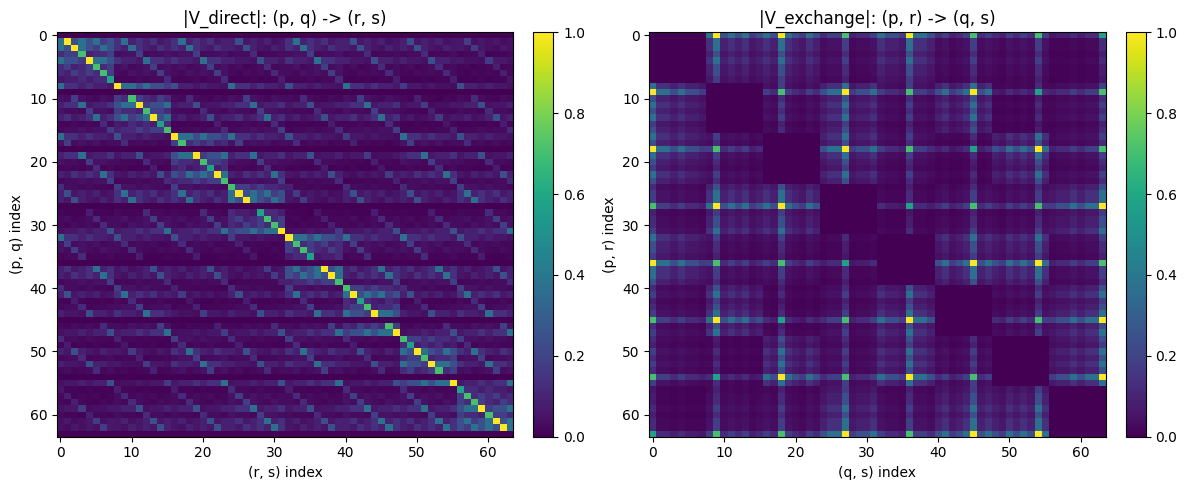

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(np.abs(V_direct), cmap="viridis", aspect="auto")
axes[0].set_title("|V_direct|: (p, q) -> (r, s)")
axes[0].set_xlabel("(r, s) index")
axes[0].set_ylabel("(p, q) index")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(np.abs(V_exchange), cmap="viridis", aspect="auto")
axes[1].set_title("|V_exchange|: (p, r) -> (q, s)")
axes[1].set_xlabel("(q, s) index")
axes[1].set_ylabel("(p, r) index")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:



qrom = QROM.build_from_data(cols, 15)
gc = get_cost_value(qrom, QECGatesCost())
